In [1]:
import numpy as np
import matplotlib.pyplot as plt
from mpl_toolkits.mplot3d import Axes3D
import networkx as nx
from optimization_script import run_optimization
import stim

In [5]:
def rho_G(m, n):
    """
    Calculates rho_G for given m and n.
    
    The formula is: rho_G = (4 * m * (n - 1)) / (m * n * (m * n - 1))
    """
    # 1. Define the condition for valid inputs (m*n > 1)
    valid_condition = (m * n > 1)
    
    # Calculate numerator and denominator for all points
    numerator = 4 * m * (n - 1)
    # The denominator calculation will safely run for all elements
    denominator = m * n * (m * n - 1)

    # 2. Use np.where to conditionally calculate the result
    # If valid_condition is True, calculate the ratio, otherwise, assign np.nan
    # np.nan ensures invalid points are ignored during plotting.
    result = np.where(valid_condition, numerator / denominator, np.nan)
    return result

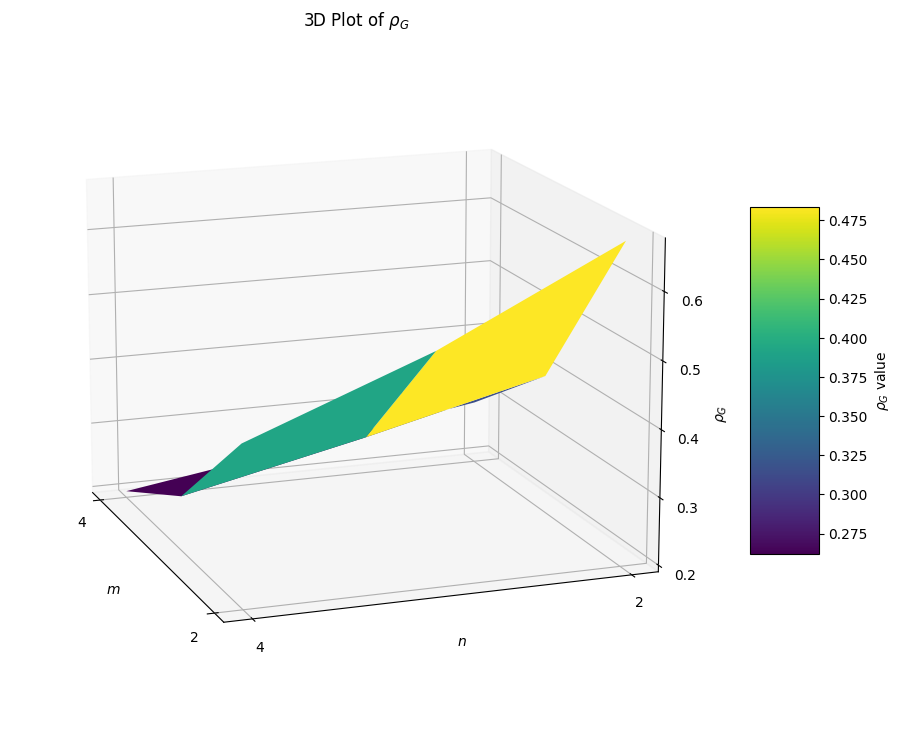

In [6]:
# --- Setup for 3D Plotting ---

# Define the ranges
m_range = np.arange(2, 5)  
n_range = np.arange(2, 5)  
# Create the meshgrid 
M, N = np.meshgrid(m_range, n_range)
# Calculate rho_G for the entire grid
Z = rho_G(M, N)

# --- Create the 3D plot ---
fig = plt.figure(figsize=(12, 9))
ax = fig.add_subplot(111, projection='3d')


# Set a new viewing angle:
ax.view_init(elev=15, azim=160)

# Create the surface plot
surface = ax.plot_surface(M, N, Z, cmap='viridis')

# Labels 
ax.set_xlabel('$m$')
ax.set_ylabel('$n$')
ax.set_zlabel('$\\rho_G$')
ax.set_title('3D Plot of $\\rho_G $')

# Color bar and ticks
fig.colorbar(surface, shrink=0.5, aspect=5, label='$\\rho_G$ value')
ax.set_xticks(m_range[::2])
ax.set_yticks(n_range[::2])

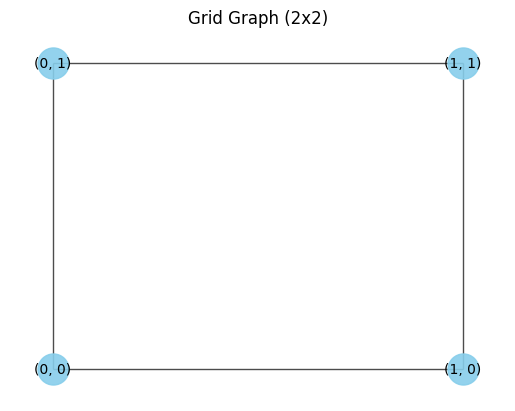

In [17]:
import networkx as nx
# 1. Create the Grid Graph
# Generate a 5x5 grid graph (rows x columns)
R = 2
C = 2
G = nx.grid_2d_graph(R, C)

# 2. Prepare the Visualization
# Use the positions naturally defined by the grid (tuples like (0,0), (0,1), etc.)
pos = {node: node for node in G.nodes()} 
# Alternatively, use a specific layout algorithm if the natural grid doesn't suffice:
# pos = nx.spring_layout(G) 

# 3. Plot the Graph
# plt.figure(figsize=(8, 8)) # Set the size of the plot

# Draw the nodes
nx.draw_networkx_nodes(G, pos, node_color='skyblue', node_size=500, alpha=0.9)

# Draw the edges
nx.draw_networkx_edges(G, pos, width=1.0, alpha=0.7)

# Draw the labels (optional: shows the coordinate of each node)
# The labels are the node tuples (e.g., (0, 0), (0, 1))
labels = {node: node for node in G.nodes()}
nx.draw_networkx_labels(G, pos, labels, font_size=10) 

# 4. Finalize and Display
plt.title(f"Grid Graph ({R}x{C})")
plt.axis('off') # Turn off the axis to show only the graph
plt.show()

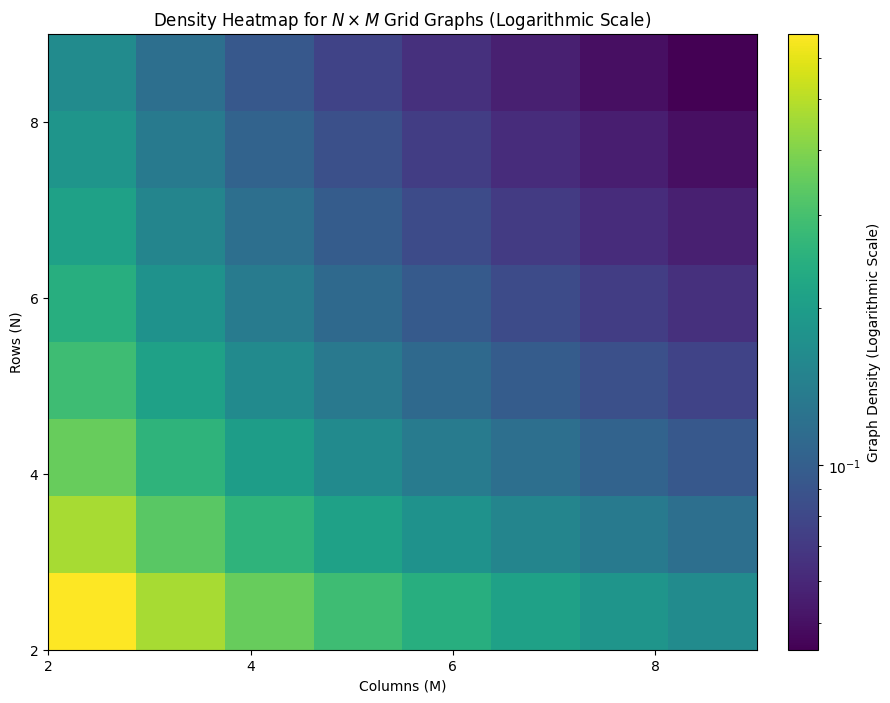

In [8]:
import networkx as nx
import numpy as np
import matplotlib.pyplot as plt
from matplotlib.colors import LogNorm

# Define the range for N (rows) and M (columns)
N_values = np.arange(2, 10)
M_values = np.arange(2, 10)

densities = []

# Calculate densities for all N x M combinations
for n in N_values:
    for m in M_values:
        g = nx.grid_2d_graph(n, m)
        den = nx.density(g)
        densities.append(den)

# Reshape the list of densities into a 19x19 matrix
density_matrix = np.array(densities).reshape(len(N_values), len(M_values))

# --- Apply Logarithmic Scale ---
# Use LogNorm to compress higher values and expand lower values
norm_log = LogNorm(vmin=density_matrix.min(), vmax=density_matrix.max())

# --- Plotting the Logarithmic Heatmap ---
plt.figure(figsize=(10, 8))

# Use imshow to create the heatmap, applying LogNorm
im = plt.imshow(density_matrix, cmap='viridis', origin='lower',
                extent=[M_values.min(), M_values.max(), N_values.min(), N_values.max()],
                aspect='auto', norm=norm_log)

# Add a color bar
cbar = plt.colorbar(im, label='Graph Density (Logarithmic Scale)', fraction=0.046, pad=0.04)

# Set ticks and labels
tick_step = 2
plt.xticks(np.arange(M_values.min(), M_values.max() + 1, tick_step))
plt.yticks(np.arange(N_values.min(), N_values.max() + 1, tick_step))

plt.xlabel('Columns (M)')
plt.ylabel('Rows (N)')
plt.title('Density Heatmap for $N \\times M$ Grid Graphs (Logarithmic Scale)')
plt.show()

number of edges before 40
40


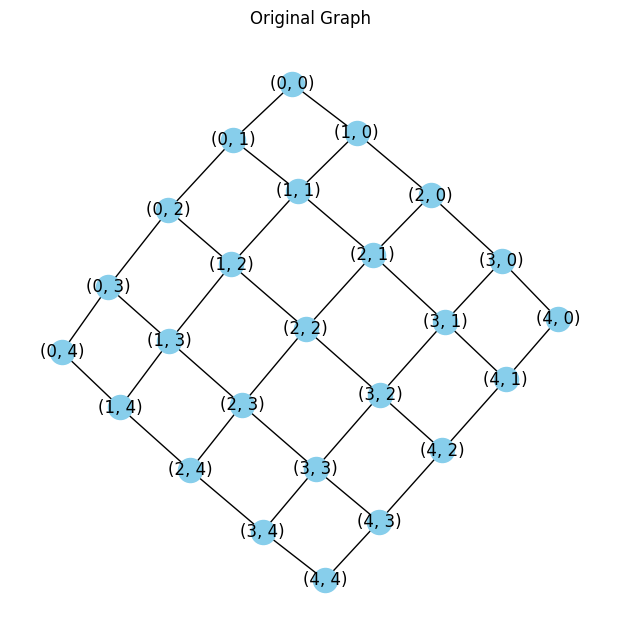

number of edges after 40


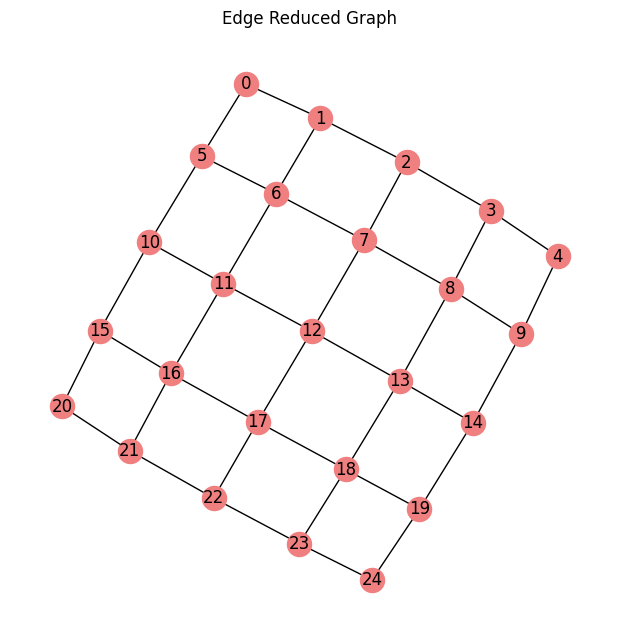

In [10]:
import networkx as nx
from optimization_script import run_optimization
from lib.circuitSolver import *
from lib.generate_graph import *
from lib.tableau import *
import pytest
import numpy as np # Ensure numpy is imported if needed by the other libs




# # --- START OF FIX: RELABELING THE NODES ---
# # Create a mapping dictionary: (0, 0) -> 0, (0, 1) -> 1, ..., (2, 2) -> 8
# mapping = {node: i for i, node in enumerate(our_graph_original.nodes())}

# # Create a new graph with integer labels
# our_graph = nx.relabel_nodes(our_graph_original, mapping)
# # --- END OF FIX ---


# # This will likely avoid the error, as the nodes are now hashable integers (0, 1, 2, ...) 
# # and not complex tuples that might be misinterpreted as array input dimensions.
# graph , circ, statistics = run_optimization(our_graph, edge_reduction=True, minLA=False, opt_CNOT= False)
# nx.draw(graph)


def check_edge_reduction(our_graph_original):
    our_graph_original
    # Create a mapping dictionary: (0, 0) -> 0, (0, 1) -> 1, ..., (2, 2) -> 8
    mapping = {node: i for i, node in enumerate(our_graph_original.nodes())}

    # Create a new graph with integer labels
    our_graph = nx.relabel_nodes(our_graph_original, mapping)
    graph , circ, statistics = run_optimization(our_graph, edge_reduction=True, minLA=False, opt_CNOT= False)
    return graph


# # Define a simple grid 
R = 5
C = 5
our_graph_original = nx.grid_2d_graph(R, C)

print('number of edges before',len(nx.edges(our_graph_original)))
# our_graph_original = nx.complete_graph(6)
print(len(nx.edges(our_graph_original)))
# 1. Plot the Original Graph
plt.figure(figsize=(6, 6)) # <--- Create the first figure
nx.draw(our_graph_original, with_labels=True, node_color='skyblue')
plt.title("Original Graph")
plt.show() # Optional in Jupyter, but good practice

edge_reduced = check_edge_reduction(our_graph_original)

print('number of edges after',len(nx.edges(edge_reduced)))
# 2. Plot the Edge Reduced Graph
plt.figure(figsize=(6, 6)) # <--- Create the second figure
nx.draw(edge_reduced, with_labels=True, node_color='lightcoral') 
plt.title("Edge Reduced Graph")
plt.show()

/Users/konstantinosrafailrevis/Desktop/PhD/0paul_state_gen/photonic-graphstate-generator-main/lib/generate_graph.py:133: RuntimeWarning: overflow encountered in divide
  if next_cost < current_cost or random.random() < np.exp((current_cost - next_cost)/temperature):


The netwrokx graph
#emmitters:  3
#emitter-CNOTs:  19
#gates-on-emitter:  58
Emission Order:  [0, 1, 2, 5, 4, 3, 8, 7, 6, 9, 10, 11, 12, 13, 14, 15, 16, 17, 20, 19, 18, 21, 22, 23, 24, 25, 26, 27, 28, 29]
Local Complementations Performed:  [13  7 22 28  1 18 19 25 16 10 15  4 13  7 18 19  4 13 17 24 19 17 16 23
  2 29 15 22  1 28]


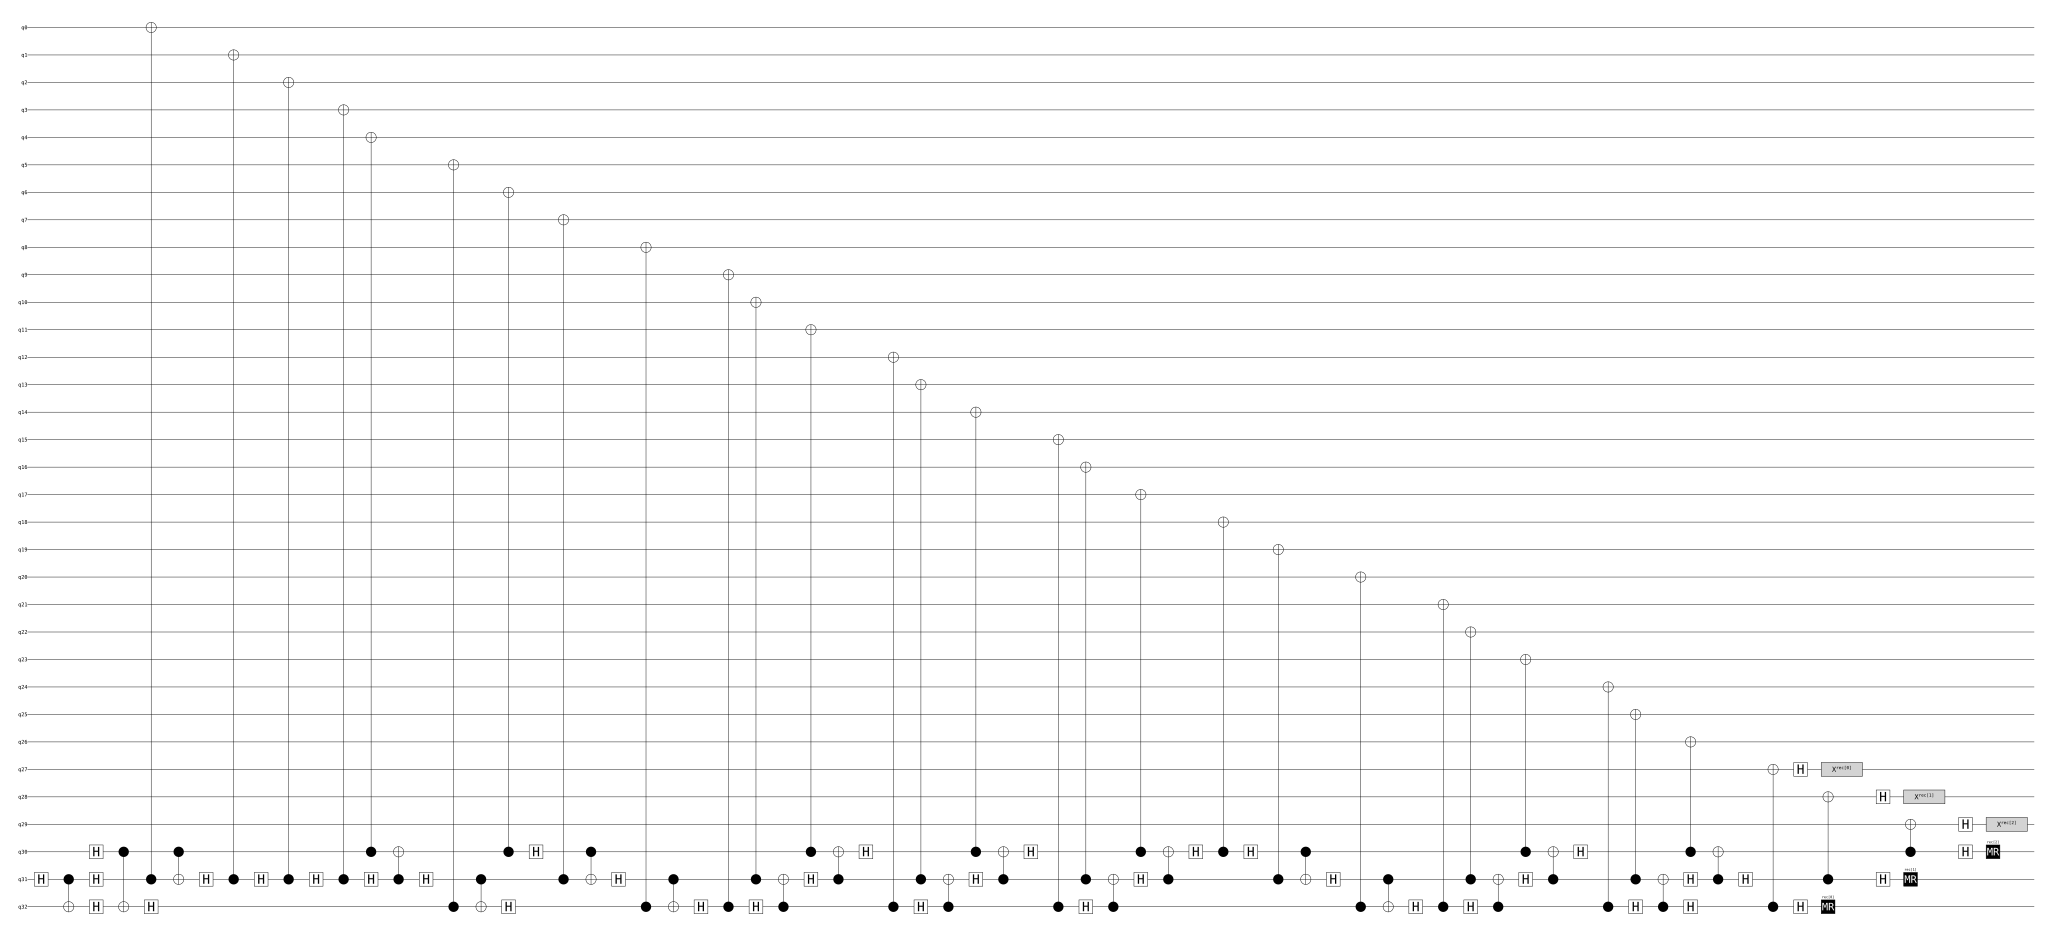

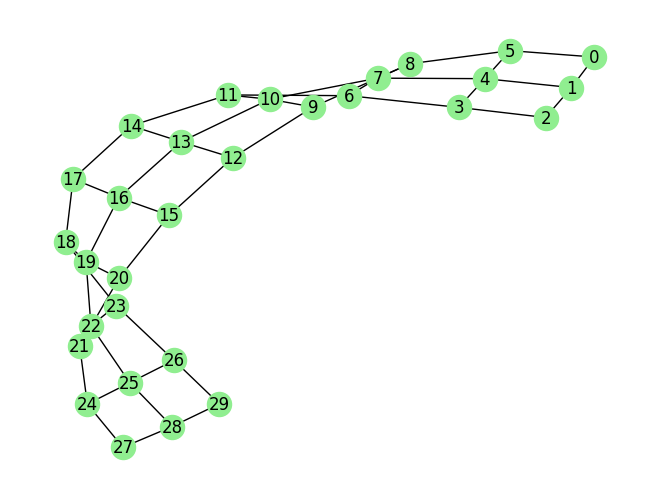

In [2]:
# Create a 4x4 grid graph
grid_graph = nx.grid_graph(dim=[3, 10])
#1 min and 50 sec for 11x11 

# Relabel the nodes to integers
grid_graph = nx.relabel_nodes(grid_graph, {node: i for i, node in enumerate(grid_graph.nodes())})

# Run the optimization scheme on the grid graph
opt_graph, circuit, stats = run_optimization(grid_graph)
print(f"The netwrokx graph")
nx.draw(opt_graph, with_labels=True, node_color='lightgreen')
# print("Statistics: ", stats)
print("#emmitters: ", stats[0])
print("#emitter-CNOTs: ", stats[1])
print("#gates-on-emitter: ", stats[2])
print("Emission Order: ", stats[3])
print("Local Complementations Performed: ", stats[4])
circuit.diagram('timeline-svg')

In [7]:
number_of_emitters = []
number_of_emitter_CNOTs = []
max_n = 11
max_m = 11
for n in range(2, max_n+1):
    for m in range(n, max_m+1):
        print(f"Running optimization for grid graph of size {n}x{m}")
        grid_graph = nx.grid_graph(dim=[n, m])
        # Relabel the nodes to integers
        grid_graph = nx.relabel_nodes(grid_graph, {node: i for i, node in enumerate(grid_graph.nodes())})
        # Run the optimization scheme on the grid graph
        opt_graph, circuit, stats = run_optimization(grid_graph)
        number_of_emitters.append(stats[0])
        number_of_emitter_CNOTs.append(stats[1])



Running optimization for grid graph of size 2x2


/Users/konstantinosrafailrevis/Desktop/PhD/0paul_state_gen/photonic-graphstate-generator-main/lib/generate_graph.py:133: RuntimeWarning: overflow encountered in divide
  if next_cost < current_cost or random.random() < np.exp((current_cost - next_cost)/temperature):


Running optimization for grid graph of size 2x3


/Users/konstantinosrafailrevis/Desktop/PhD/0paul_state_gen/photonic-graphstate-generator-main/lib/generate_graph.py:133: RuntimeWarning: overflow encountered in divide
  if next_cost < current_cost or random.random() < np.exp((current_cost - next_cost)/temperature):


Running optimization for grid graph of size 2x4
Running optimization for grid graph of size 2x5
Running optimization for grid graph of size 2x6
Running optimization for grid graph of size 2x7
Running optimization for grid graph of size 2x8
Running optimization for grid graph of size 2x9
Running optimization for grid graph of size 2x10
Running optimization for grid graph of size 2x11
Running optimization for grid graph of size 3x3
Running optimization for grid graph of size 3x4
Running optimization for grid graph of size 3x5
Running optimization for grid graph of size 3x6
Running optimization for grid graph of size 3x7
Running optimization for grid graph of size 3x8
Running optimization for grid graph of size 3x9
Running optimization for grid graph of size 3x10
Running optimization for grid graph of size 3x11
Running optimization for grid graph of size 4x4
Running optimization for grid graph of size 4x5
Running optimization for grid graph of size 4x6
Running optimization for grid graph 

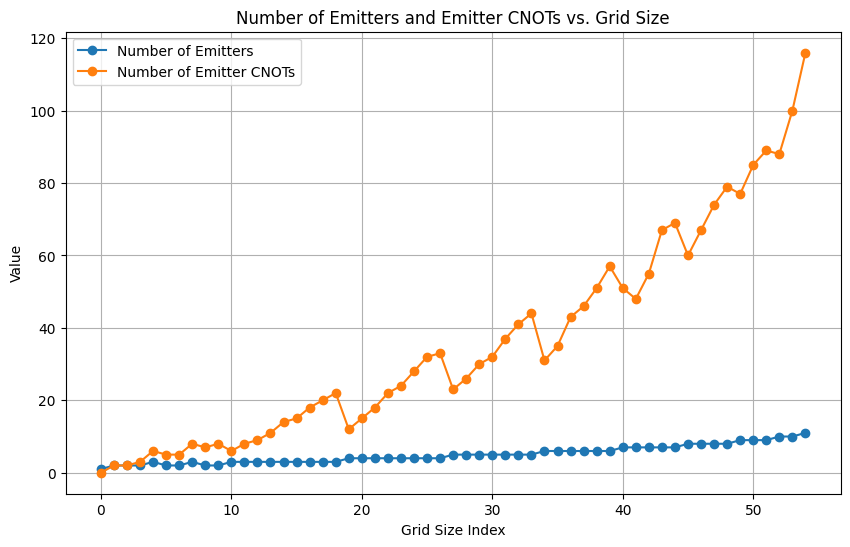

In [222]:
# Create the line plot for number_of_emitters
plt.figure(figsize=(10, 6))
plt.plot(range(len(number_of_emitters)), number_of_emitters, marker='o',label='Number of Emitters')

# Create the line plot for number_of_emitter_CNOTs
plt.plot(range(len(number_of_emitter_CNOTs)), number_of_emitter_CNOTs,marker='o' ,label='Number of Emitter CNOTs')

# Set the labels
plt.xlabel('Grid Size Index')
plt.ylabel('Value')

# Set the title
plt.title('Number of Emitters and Emitter CNOTs vs. Grid Size')

# Add legend
plt.legend()

# Set the y-axis to show only integers
# plt.yticks(range(min(min(number_of_emitters), min(number_of_emitter_CNOTs)), max(max(number_of_emitters), max(number_of_emitter_CNOTs))+1))

# Add a grid to the plot
plt.grid(True)

# Show the plot
plt.show()

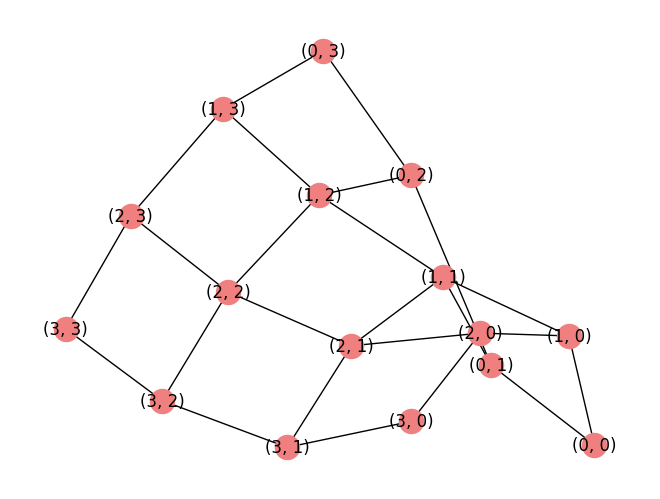

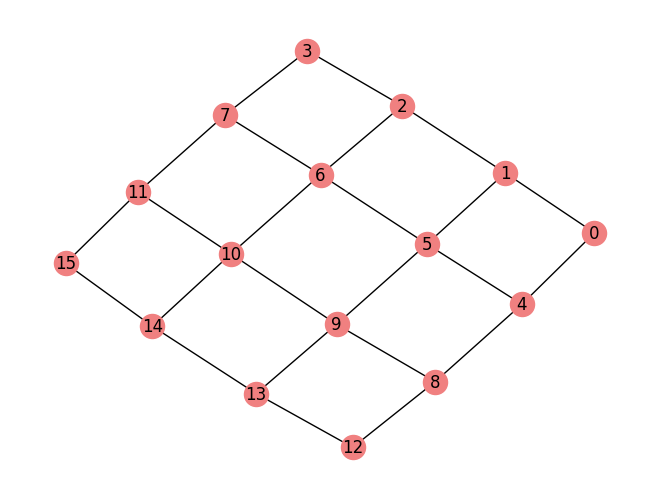

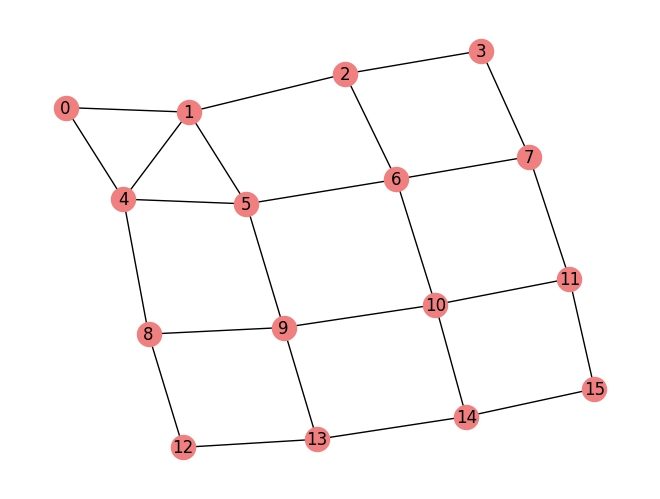

In [100]:
# function to apply a series of random local complementations to a graph
# from lib import LC_edge_reduction
from lib.LC_edge_reduction import LCReduction

R = 4
C = 4

initial  = nx.grid_2d_graph(R, C)
nx.draw(initial, with_labels=True, node_color='lightcoral') 
plt.show()
mapping = {node: i for i, node in enumerate(initial.nodes())}

# Create a new graph with integer labels
relabel_initial_graph = nx.relabel_nodes(initial, mapping)

nx.draw(relabel_initial_graph, with_labels=True, node_color='lightcoral') 
plt.show()


result = LCReduction.random_LC(relabel_initial_graph, 1)

nx.draw(result, with_labels=True, node_color='lightcoral') 



Creating database for grid graph of size 2x2
Creating database for grid graph of size 2x3
Creating database for grid graph of size 2x4
Creating database for grid graph of size 2x5
Creating database for grid graph of size 2x6
Creating database for grid graph of size 2x7
Creating database for grid graph of size 2x8
Creating database for grid graph of size 2x9
Creating database for grid graph of size 2x10
Creating database for grid graph of size 2x11
Creating database for grid graph of size 3x3
Creating database for grid graph of size 3x4
Creating database for grid graph of size 3x5
Creating database for grid graph of size 3x6
Creating database for grid graph of size 3x7
Creating database for grid graph of size 3x8
Creating database for grid graph of size 3x9
Creating database for grid graph of size 3x10
Creating database for grid graph of size 3x11
Creating database for grid graph of size 4x4
Creating database for grid graph of size 4x5
Creating database for grid graph of size 4x6
Creati

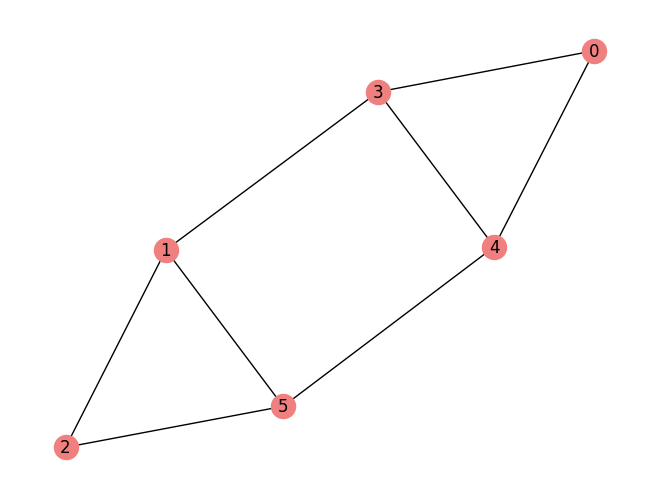

In [ ]:
#ready to create a database of graph families created from random local complementations on grid graphs
repetition_for_each_size = 20 #number of graphs to create for each grid size
max_n = 11  # max number of rows
max_m = 11 # max number of columns

#dictionary to hold the database
graph_database = {}

for n in range(2, max_n+1): 
    for m in range(n, max_m+1): #do not repeat n x m and m x n
        print(f"Creating database for grid graph of size {n}x{m}")
        #initial grid graph
        initial  = nx.grid_2d_graph(n, m)
        #relabel nodes to integers  
        mapping = {node: i for i, node in enumerate(initial.nodes())}

        graph_family = []

        relabel_initial_graph = nx.relabel_nodes(initial, mapping)
        #apply 10 random local complementations on the relabeled grid graph
        for _ in range(repetition_for_each_size):
            result = LCReduction.random_LC(relabel_initial_graph, 10)
            graph_family.append(result)
        
        graph_database[(m,n)] = graph_family

# example_graph = graph_database[(3,2)][1] 
# nx.draw(example_graph, with_labels=True, node_color='lightcoral')
# plt.show()

In [133]:
import pickle
# Save the dictionary
filename = 'graph_database.pkl'
with open(filename, 'wb') as file:
    # 'wb' means 'write binary'
    pickle.dump(graph_database, file)

print(f"Graph database successfully saved to .../path/{filename}")


Graph database successfully saved to .../path/graph_database.pkl


In [147]:
graph_database[(3,2)]

In [ ]:
# graph_database[(2,2)][0]

#TODO: run a full scale optimization test on the created database and store the results
number_of_emitters_cluster_family = {}
number_of_emitter_CNOTs_cluster_family = {}
max_n = 11
max_m = 11
for n in range(2, max_n+1):
    for m in range(n, max_m+1):
        print(f"------------------Running optimization for the cluster family {n}x{m}------------------")
        temp_number_of_emitters_cluster_family = []
        temp_number_of_emitter_CNOTs_cluster_family= []
        for i in range(len(graph_database[(m,n)])): #TODO no idea why (m,n) but it works
            print(f"Testing graph {i+1}")
            test_graph = graph_database[(m,n)][i] #TODO no idea why (m,n) but it works
            opt_graph, circuit, stats = run_optimization(test_graph)
            temp_number_of_emitters_cluster_family.append(stats[0])
            # print(f"#emmitters: ", stats[0])
            temp_number_of_emitter_CNOTs_cluster_family.append(stats[1])
            # print(f"#emitter-CNOTs: ", stats[1])
        
        number_of_emitters_cluster_family[(n,m)] = temp_number_of_emitters_cluster_family
        number_of_emitter_CNOTs_cluster_family[(n,m)] = temp_number_of_emitter_CNOTs_cluster_family



------------------Running optimization for the cluster family 2x2------------------
Testing graph 1


/Users/konstantinosrafailrevis/Desktop/PhD/0paul_state_gen/photonic-graphstate-generator-main/lib/generate_graph.py:133: RuntimeWarning: overflow encountered in divide
  if next_cost < current_cost or random.random() < np.exp((current_cost - next_cost)/temperature):


Testing graph 2
Testing graph 3
Testing graph 4
Testing graph 5
Testing graph 6
Testing graph 7
Testing graph 8
Testing graph 9
Testing graph 10
Testing graph 11
Testing graph 12
Testing graph 13
Testing graph 14
Testing graph 15
Testing graph 16
Testing graph 17
Testing graph 18
Testing graph 19
Testing graph 20
------------------Running optimization for the cluster family 2x3------------------
Testing graph 1
Testing graph 2
Testing graph 3
Testing graph 4
Testing graph 5
Testing graph 6
Testing graph 7
Testing graph 8
Testing graph 9
Testing graph 10
Testing graph 11
Testing graph 12
Testing graph 13
Testing graph 14
Testing graph 15
Testing graph 16
Testing graph 17
Testing graph 18
Testing graph 19
Testing graph 20
------------------Running optimization for the cluster family 2x4------------------
Testing graph 1
Testing graph 2
Testing graph 3
Testing graph 4
Testing graph 5
Testing graph 6
Testing graph 7
Testing graph 8
Testing graph 9
Testing graph 10
Testing graph 11
Testing 

In [180]:
import pickle
# Save the dictionary
filename = 'graph_database_results_for_cluster_family_number_of_emitters_cluster_family.pkl'
with open(filename, 'wb') as file:
    # 'wb' means 'write binary'
    pickle.dump(number_of_emitters_cluster_family, file)

print(f"Number of emitters for cluster family successfully saved to .../path/{filename}")

filename = 'graph_database_results_for_cluster_family_number_of_emitter_CNOTs_cluster_family.pkl'
with open(filename, 'wb') as file:
    # 'wb' means 'write binary'
    pickle.dump(number_of_emitter_CNOTs_cluster_family, file)

print(f"Number of emitters CNOTS for cluster family successfully saved to .../path/{filename}")

Number of emitters for cluster family successfully saved to .../path/graph_database_results_for_cluster_family_number_of_emitters_cluster_family.pkl
Number of emitters CNOTS for cluster family successfully saved to .../path/graph_database_results_for_cluster_family_number_of_emitter_CNOTs_cluster_family.pkl


In [181]:
#import the data for future usage
# The same filename used when saving
filename = 'graph_database_results_for_cluster_family_number_of_emitters_cluster_family.pkl'

# Open the file in read-binary mode
with open(filename, 'rb') as file:  # 'rb' means 'read binary'
    number_of_emitters_cluster_family_load_test = pickle.load(file)


print(number_of_emitters_cluster_family_load_test)


filename = 'graph_database_results_for_cluster_family_number_of_emitter_CNOTs_cluster_family.pkl'

# Open the file in read-binary mode
with open(filename, 'rb') as file:  # 'rb' means 'read binary'
    number_of_emitter_CNOTs_cluster_family_load_test = pickle.load(file)


print(number_of_emitter_CNOTs_cluster_family_load_test)


{(2, 2): [1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1], (2, 3): [2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2], (2, 4): [3, 3, 3, 3, 2, 2, 2, 2, 3, 2, 2, 2, 2, 2, 2, 2, 3, 2, 3, 3], (2, 5): [3, 3, 3, 4, 3, 3, 2, 4, 3, 3, 3, 3, 3, 2, 3, 3, 3, 3, 3, 3], (2, 6): [2, 2, 4, 3, 2, 3, 2, 3, 2, 2, 3, 2, 2, 3, 2, 3, 3, 3, 3, 4], (2, 7): [3, 2, 3, 2, 3, 2, 3, 3, 3, 2, 3, 4, 2, 3, 3, 3, 3, 2, 3, 3], (2, 8): [3, 3, 3, 2, 3, 2, 3, 3, 3, 2, 2, 2, 3, 3, 3, 3, 3, 3, 3, 3], (2, 9): [2, 2, 3, 3, 3, 3, 3, 3, 3, 2, 3, 3, 3, 3, 3, 3, 3, 3, 3, 3], (2, 10): [3, 3, 3, 3, 3, 2, 2, 2, 3, 3, 4, 3, 3, 3, 3, 3, 3, 3, 3, 3], (2, 11): [3, 3, 3, 4, 3, 3, 3, 3, 3, 3, 3, 3, 3, 3, 2, 3, 3, 3, 3, 3], (3, 3): [3, 3, 3, 3, 3, 3, 3, 3, 3, 3, 3, 3, 3, 3, 3, 3, 3, 3, 3, 3], (3, 4): [4, 4, 4, 4, 4, 3, 4, 3, 4, 4, 3, 3, 4, 5, 4, 3, 4, 3, 4, 4], (3, 5): [3, 4, 5, 3, 4, 5, 3, 4, 4, 4, 3, 3, 3, 3, 4, 4, 4, 4, 4, 4], (3, 6): [4, 5, 5, 4, 4, 5, 3, 4, 4, 5, 4, 3, 4, 4, 3, 5, 4, 4, 3, 4], (3, 7): [4, 5, 3,

In [ ]:

mean_emitters_cluster_family = []
std_emitters_cluster_family = []

max_n = 11
max_m = 11
for n in range(2, max_n+1):
    for m in range(n, max_m+1):
        print(f"------------------Running statistics for the cluster family {n}x{m}------------------")
        print("Original number of emitter for the cluster state")
        print("Complete list",number_of_emitters_cluster_family[(n,m)])
        mean_emitters_cluster_family.append(np.mean(number_of_emitters_cluster_family[(n,m)]))
        print("Mean for the list:",np.mean(number_of_emitters_cluster_family[(n,m)]))
        std_emitters_cluster_family.append(np.std(number_of_emitters_cluster_family[(n,m)]))
        print("STD for the list:",np.std(number_of_emitters_cluster_family[(n,m)]))

------------------Running statistics for the cluster family 2x2------------------
Original number of emitter for the cluster state
Complete list [1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1]
Mean for the list: 1.0
STD for the list: 0.0
------------------Running statistics for the cluster family 2x3------------------
Original number of emitter for the cluster state
Complete list [2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2]
Mean for the list: 2.0
STD for the list: 0.0
------------------Running statistics for the cluster family 2x4------------------
Original number of emitter for the cluster state
Complete list [3, 3, 3, 3, 2, 2, 2, 2, 3, 2, 2, 2, 2, 2, 2, 2, 3, 2, 3, 3]
Mean for the list: 2.4
STD for the list: 0.48989794855663565
------------------Running statistics for the cluster family 2x5------------------
Original number of emitter for the cluster state
Complete list [3, 3, 3, 4, 3, 3, 2, 4, 3, 3, 3, 3, 3, 2, 3, 3, 3, 3, 3, 3]
Mean for the list: 3.0
ST

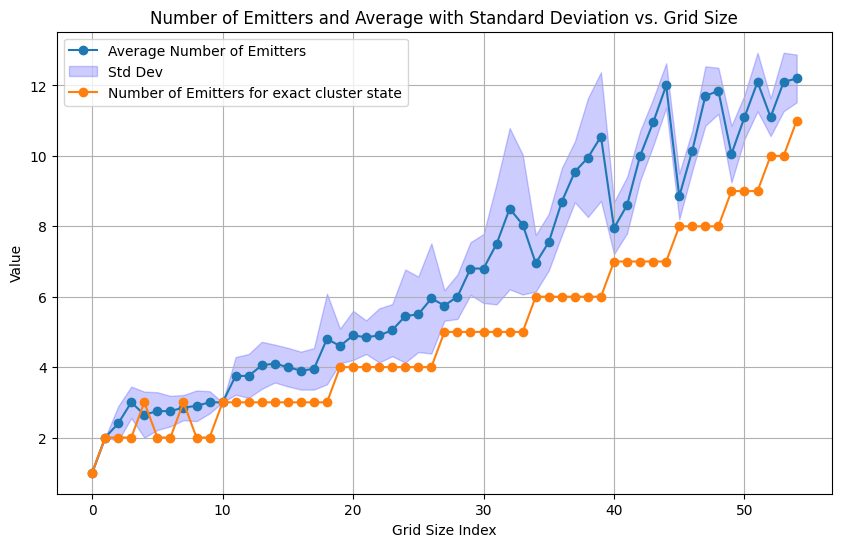

In [218]:
import matplotlib.pyplot as plt

x = range(len(number_of_emitters))  # assuming all arrays have the same length

plt.figure(figsize=(10, 6))

# Plot the mean number of emitters
plt.plot(x, mean_emitters_cluster_family, marker='o', label='Average Number of Emitters')

# Add shaded area for standard deviation
plt.fill_between(x,
                 [m - s for m, s in zip(mean_emitters_cluster_family, std_emitters_cluster_family)],
                 [m + s for m, s in zip(mean_emitters_cluster_family, std_emitters_cluster_family)],
                 color='blue', alpha=0.2, label='Std Dev')

# Plot the exact number of emitters
plt.plot(x, number_of_emitters, marker='o', label='Number of Emitters for exact cluster state')

# Labels and title
plt.xlabel('Grid Size Index')
plt.ylabel('Value')
plt.title('Number of Emitters and Average with Standard Deviation vs. Grid Size')

# Add legend
plt.legend()

# Add grid
plt.grid(True)

# Show plot
plt.show()


In [235]:
number_of_emitter_CNOTs_cluster_family[(2,9)]

[6, 6, 17, 8, 14, 14, 19, 7, 15, 6, 13, 17, 11, 17, 12, 11, 12, 19, 8, 14]

In [236]:

mean_emitters_cluster_family_cnots = []
std_emitters_cluster_family_cnots = []

max_n = 11
max_m = 11
for n in range(2, max_n+1):
    for m in range(n, max_m+1):
        print(f"------------------Running statistics for the cluster family {n}x{m}------------------")
        print("Original number of emitter for the cluster state")
        print("Complete list",number_of_emitter_CNOTs_cluster_family[(n,m)])
        mean_emitters_cluster_family_cnots.append(np.mean(number_of_emitter_CNOTs_cluster_family[(n,m)]))
        print("Mean for the list:",np.mean(number_of_emitter_CNOTs_cluster_family[(n,m)]))
        std_emitters_cluster_family_cnots.append(np.std(number_of_emitter_CNOTs_cluster_family[(n,m)]))
        print("STD for the list:",np.std(number_of_emitter_CNOTs_cluster_family[(n,m)]))

------------------Running statistics for the cluster family 2x2------------------
Original number of emitter for the cluster state
Complete list [0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0]
Mean for the list: 0.0
STD for the list: 0.0
------------------Running statistics for the cluster family 2x3------------------
Original number of emitter for the cluster state
Complete list [2, 4, 2, 2, 2, 3, 2, 4, 2, 3, 2, 2, 2, 2, 4, 2, 2, 2, 2, 2]
Mean for the list: 2.4
STD for the list: 0.7348469228349536
------------------Running statistics for the cluster family 2x4------------------
Original number of emitter for the cluster state
Complete list [6, 6, 6, 7, 2, 2, 3, 2, 6, 2, 2, 2, 2, 3, 2, 2, 8, 3, 8, 6]
Mean for the list: 4.0
STD for the list: 2.23606797749979
------------------Running statistics for the cluster family 2x5------------------
Original number of emitter for the cluster state
Complete list [8, 4, 6, 12, 6, 4, 4, 10, 6, 5, 5, 6, 6, 3, 10, 5, 8, 7, 6, 4]
Mean for t

In [237]:
# mean_emitters_cluster_family_cnots
# std_emitters_cluster_family_cnots 

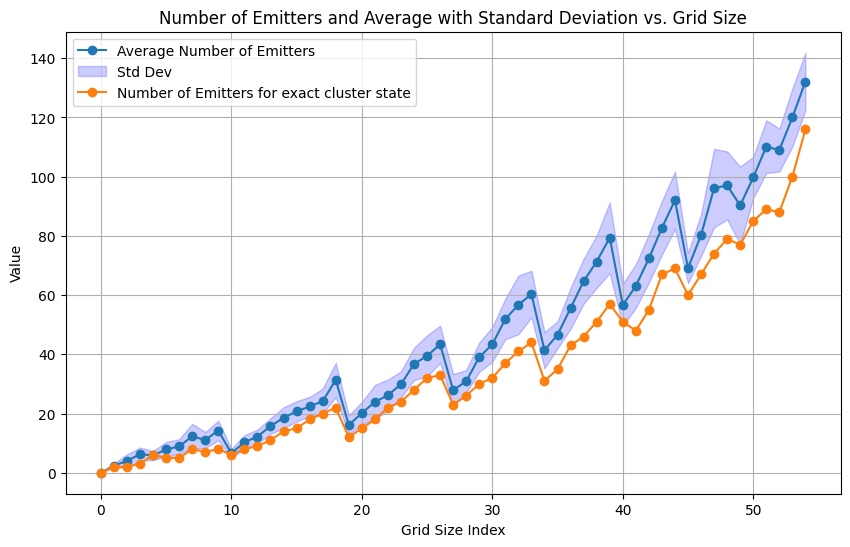

In [238]:
import matplotlib.pyplot as plt

x = range(len(number_of_emitters))  # assuming all arrays have the same length

plt.figure(figsize=(10, 6))

# Plot the mean number of emitters
plt.plot(x, mean_emitters_cluster_family_cnots, marker='o', label='Average Number of Emitters')

# Add shaded area for standard deviation
plt.fill_between(x,
                 [m - s for m, s in zip(mean_emitters_cluster_family_cnots, std_emitters_cluster_family_cnots )],
                 [m + s for m, s in zip(mean_emitters_cluster_family_cnots, std_emitters_cluster_family_cnots )],
                 color='blue', alpha=0.2, label='Std Dev')

# Plot the exact number of emitters
plt.plot(x, number_of_emitter_CNOTs, marker='o', label='Number of Emitters for exact cluster state')

# Labels and title
plt.xlabel('Grid Size Index')
plt.ylabel('Value')
plt.title('Number of Emitters and Average with Standard Deviation vs. Grid Size')

# Add legend
plt.legend()

# Add grid
plt.grid(True)

# Show plot
plt.show()

#### Checking algo for an LC-LU counter example

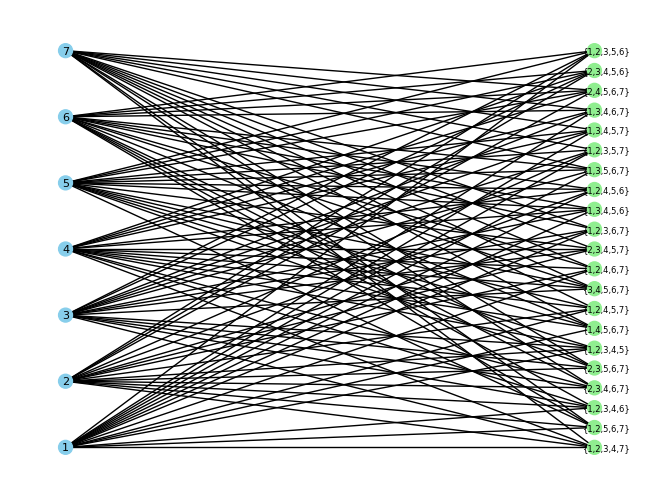

In [4]:
import networkx as nx
from itertools import combinations
import matplotlib.pyplot as plt

def create_G1():
    """
    Creates the bipartite graph G1:
    - Left side: 7 vertices labeled 1, 2, 3, 4, 5, 6, 7
    - Right side: 21 vertices labeled as sets {i,j,k,l,m} representing
      all 5-element subsets of the left side
    - Each right vertex is connected to exactly those 5 left vertices
    """
    G = nx.Graph()
    left_nodes = list(range(1, 8))
    G.add_nodes_from(left_nodes, bipartite=0)

    for subset in combinations(left_nodes, 5):
        node_label = "{" + ",".join(map(str, subset)) + "}"
        G.add_node(node_label, bipartite=1)
        for v in subset:
            G.add_edge(node_label, v)
    return G


lclu_counter_1 = create_G1()

# Compute bipartite layout
left_nodes = [n for n, d in lclu_counter_1.nodes(data=True) if d["bipartite"] == 0]
pos = nx.bipartite_layout(lclu_counter_1, left_nodes)

# Draw nodes and edges
nx.draw(lclu_counter_1, pos, with_labels=False, node_size=100,
        node_color=["skyblue" if d["bipartite"] == 0 else "lightgreen" for n, d in lclu_counter_1.nodes(data=True)])

# Separate labels for left and right nodes
labels_left = {n: n for n in left_nodes}
labels_right = {n: n for n in lclu_counter_1 if n not in left_nodes}

# Shift right-hand labels to the right
label_offset = 0.03  # adjust as needed
pos_labels_right = {n: (x + label_offset, y) for n, (x, y) in pos.items() if n in labels_right}

# Draw labels
nx.draw_networkx_labels(lclu_counter_1, pos, labels=labels_left, font_size=8)
nx.draw_networkx_labels(lclu_counter_1, pos_labels_right, labels=labels_right, font_size=6)

plt.show()


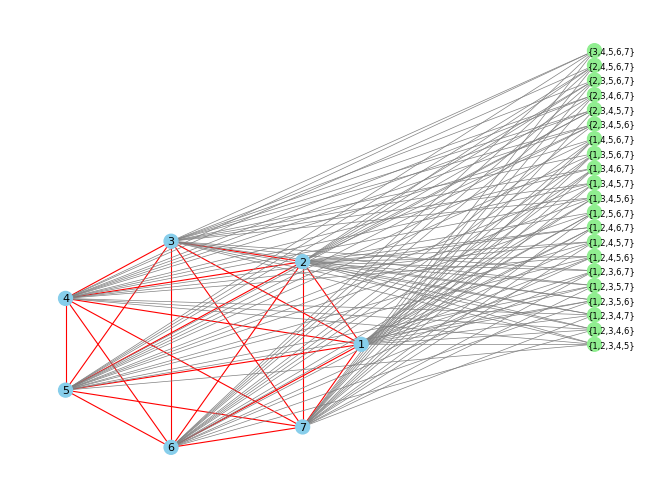

In [6]:
import networkx as nx
from itertools import combinations
import matplotlib.pyplot as plt

def create_G1_with_complete_left():
    """
    Creates a graph where:
    - Left side (1–7) form a complete graph K7
    - Right side: 21 vertices labeled by all 5-element subsets of {1,…,7}
    - Each right vertex connected to its corresponding 5 left vertices
    """
    G = nx.Graph()
    left_nodes = list(range(1, 8))
    G.add_nodes_from(left_nodes, bipartite=0)

    for subset in combinations(left_nodes, 5):
        label = "{" + ",".join(map(str, subset)) + "}"
        G.add_node(label, bipartite=1)
        for v in subset:
            G.add_edge(label, v)

    # Make left-hand nodes a complete graph (K7)
    for u, v in combinations(left_nodes, 2):
        G.add_edge(u, v)

    return G


# Create the graph
lclu_counter_2 = create_G1_with_complete_left()

# Identify left/right nodes
left_nodes = [n for n, d in lclu_counter_2.nodes(data=True) if d["bipartite"] == 0]
right_nodes = [n for n in lclu_counter_2 if n not in left_nodes]

# Layout: left-hand side as complete graph (K7)
pos_left = nx.circular_layout(left_nodes, scale=1.8)

# Shift the K7 to the left
for n in pos_left:
    pos_left[n] = (pos_left[n][0] - 2, pos_left[n][1])

# Arrange right-hand nodes vertically to the right
pos_right = {n: (2.5, i * 0.25) for i, n in enumerate(right_nodes)}

# Merge positions
pos = {**pos_left, **pos_right}

# Draw graph
nx.draw(
    lclu_counter_2,
    pos,
    with_labels=False,
    node_size=100,
    node_color=["skyblue" if n in left_nodes else "lightgreen" for n in lclu_counter_2.nodes()],
    edge_color=[
        "red" if (u in left_nodes and v in left_nodes) else "gray" for u, v in lclu_counter_2.edges()
    ],
    width=[
        0.8 if (u in left_nodes and v in left_nodes) else 0.5 for u, v in lclu_counter_2.edges()
    ]
)

# Draw labels (right ones slightly offset)
labels_left = {n: n for n in left_nodes}
labels_right = {n: n for n in right_nodes}
pos_labels_right = {n: (x + 0.2, y) for n, (x, y) in pos_right.items()}

nx.draw_networkx_labels(lclu_counter_2, pos, labels=labels_left, font_size=8)
nx.draw_networkx_labels(lclu_counter_2, pos_labels_right, labels=labels_right, font_size=6)

plt.axis("off")
plt.show()


/Users/konstantinosrafailrevis/Desktop/PhD/0paul_state_gen/photonic-graphstate-generator-main/lib/generate_graph.py:133: RuntimeWarning: overflow encountered in divide
  if next_cost < current_cost or random.random() < np.exp((current_cost - next_cost)/temperature):


The netwrokx graph
#emmitters:  7
#emitter-CNOTs:  71
#gates-on-emitter:  144
Emission Order:  [17, 16, 18, 26, 14, 6, 2, 3, 21, 10, 8, 13, 11, 1, 20, 7, 24, 22, 5, 19, 12, 15, 25, 9, 0, 23, 27, 4]
Local Complementations Performed:  [14 21  2 17 13 14  0 23  8  2 27  1]


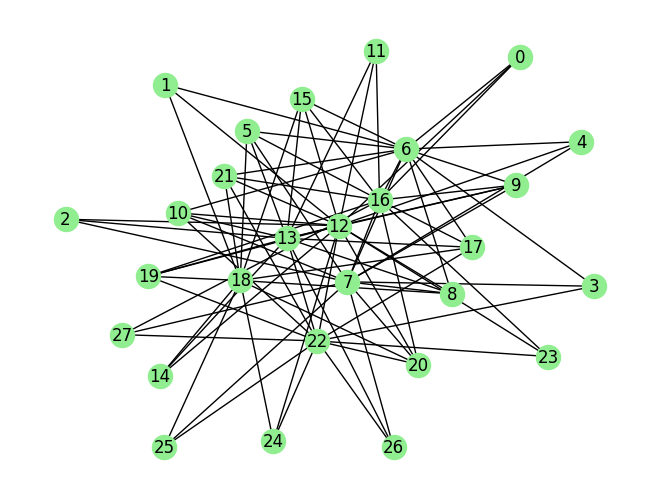

In [12]:
# Create a 4x4 grid graph
graph_tested = lclu_counter_1
#1 min and 50 sec for 11x11 

# Relabel the nodes to integers
graph_tested = nx.relabel_nodes(graph_tested, {node: i for i, node in enumerate(graph_tested.nodes())})

# Run the optimization scheme on the grid graph
opt_graph_1, circuit_1, stats_1 = run_optimization(graph_tested)
print(f"The netwrokx graph")
nx.draw(opt_graph_1, with_labels=True, node_color='lightgreen')
# print("Statistics: ", stats)
print("#emmitters: ", stats_1[0])
print("#emitter-CNOTs: ", stats_1[1])
print("#gates-on-emitter: ", stats_1[2])
print("Emission Order: ", stats_1[3])
print("Local Complementations Performed: ", stats_1[4])
# circuit.diagram('timeline-svg')


The netwrokx graph
#emmitters:  7
#emitter-CNOTs:  56
#gates-on-emitter:  104
Emission Order:  [7, 20, 22, 10, 19, 21, 11, 6, 3, 13, 9, 8, 14, 23, 17, 4, 1, 2, 0, 27, 16, 18, 24, 12, 25, 26, 5, 15]
Local Complementations Performed:  [21  6 11 21 20 25 13 18  1 23 17  6]


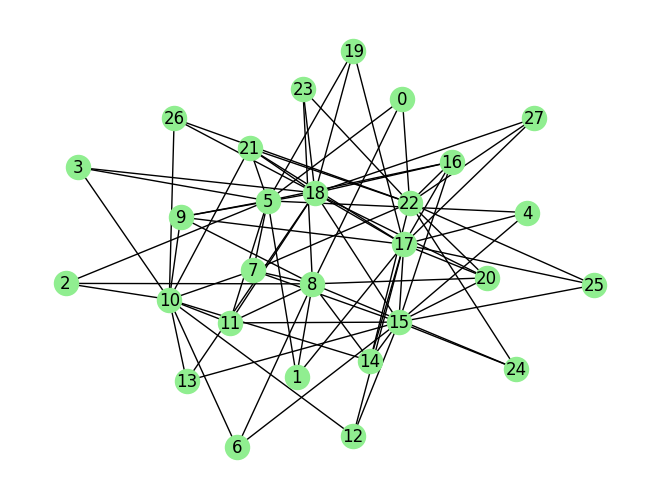

In [13]:
# Create a 4x4 grid graph
graph_tested = lclu_counter_2
#1 min and 50 sec for 11x11 

# Relabel the nodes to integers
graph_tested = nx.relabel_nodes(graph_tested, {node: i for i, node in enumerate(graph_tested.nodes())})

# Run the optimization scheme on the grid graph
opt_graph_2, circuit_2, stats_2 = run_optimization(graph_tested)
print(f"The netwrokx graph")
nx.draw(opt_graph_2, with_labels=True, node_color='lightgreen')
# print("Statistics: ", stats)
print("#emmitters: ", stats_2[0])
print("#emitter-CNOTs: ", stats_2[1])
print("#gates-on-emitter: ", stats_2[2])
print("Emission Order: ", stats_2[3])
print("Local Complementations Performed: ", stats_2[4])
# circuit.diagram('timeline-svg')

In [14]:
print("Difference between the two graphs optimization results #emitters (state1 - state2):", stats_1[0] - stats_2[0])
print("Difference between the two graphs optimization results #emitter CNOTs (state1 - state2):", stats_1[1] - stats_2[1])
print("Difference between the two graphs optimization results #gates-on-emitter (state1 - state2):", stats_1[2] - stats_2[2])

Difference between the two graphs optimization results #emitters (state1- state2): 0
Difference between the two graphs optimization results #emitter CNOTs (state1- state2): 15
Difference between the two graphs optimization results #gates-on-emitter (state1- state2): 40
